---
title: Imports
jupyter:
  jupytext:
    text_representation:
      extension: .qmd
      format_name: quarto
      format_version: '1.0'
      jupytext_version: 1.17.3
  kernelspec:
    display_name: lista-4-projekt-grupowy-1 (3.14.3)
    language: python
    name: python3
---


In [1]:
import sys
sys.path.insert(0, "..")

In [2]:
from numpy.typing import NDArray
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import classification_report, confusion_matrix, RocCurveDisplay, PrecisionRecallDisplay, precision_recall_curve, roc_curve
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV, GroupKFold, cross_val_predict
from sklearn.metrics import confusion_matrix
from scripts.utils import load_preprocess_split, custom_score, cost_score
from pathlib import Path
from numpy.typing import NDArray
from typing import cast

In [3]:
train_df, test_df = load_preprocess_split(Path("../data/neo_v2.csv"))

groups_train = train_df["id"]
X_train = train_df.drop(columns=["id", "hazardous"])
y_train = train_df["hazardous"]
X_test = test_df.drop(columns=["id", "hazardous"])
y_test = test_df["hazardous"]

In [5]:
pipeline = Pipeline([
    ('scaler', RobustScaler()),
    ('svc', SVC(probability=False, random_state=42))
])

param_grid = [
    {
        'svc__kernel': ['rbf'],
        'svc__C': [0.01, 0.1, 1.0],
        'svc__gamma': ['scale', 'auto', 0.001, 0.01, 0.1],
        'svc__class_weight': ['balanced', {False: 1, True: 100}, {False: 1, True: 1000}]
    },
]

In [6]:
gkf = GroupKFold(n_splits=5)

grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    scoring=cost_score,
    cv=gkf,
    n_jobs=-1,
    verbose=2,
)

In [7]:
grid_search.fit(X_train, y_train, groups=groups_train)

print(f"Najlepsze parametry: {grid_search.best_params_}")
best_model = grid_search.best_estimator_

Fitting 5 folds for each of 45 candidates, totalling 225 fits


Najlepsze parametry: {'svc__C': 0.01, 'svc__class_weight': {False: 1, True: 100}, 'svc__gamma': 'auto', 'svc__kernel': 'rbf'}


Własny scorer zostaje użyty w tym miejscu, tak aby przesunąć granicę modelu, w sposób zapewniający 0 FN

In [8]:
cv_decision = cross_val_predict(
    best_model,
    X_train,
    y_train,
    groups=groups_train,
    cv=gkf,
    method="decision_function",
    n_jobs=-1
)
cv_decision = cast(NDArray, cv_decision)

margin = 0.5
thresholds = np.linspace(cv_decision.min() - margin, cv_decision.max() + margin, 501)
cv_costs = []

for thr in thresholds:
    y_cv_pred = (cv_decision >= thr).astype(int)
    cv_costs.append(custom_score(y_train, y_cv_pred))

best_thr = float(thresholds[int(np.argmin(cv_costs))])
print(f"Najlepszy próg SVM z CV (Decision Function): {best_thr:.3f}")
print(f"Minimalny koszt na zbiorze walidacyjnym (Out-Of-Fold): {min(cv_costs):.0f}")

Najlepszy próg SVM z CV (Decision Function): 0.525
Minimalny koszt na zbiorze walidacyjnym (Out-Of-Fold): 18748


In [9]:
y_test_scores = best_model.decision_function(X_test)
final_predictions = (y_test_scores >= best_thr).astype(int)

print(classification_report(y_test, final_predictions))

              precision    recall  f1-score   support

       False       1.00      0.71      0.83     16379
        True       0.26      1.00      0.41      1674

    accuracy                           0.73     18053
   macro avg       0.63      0.85      0.62     18053
weighted avg       0.93      0.73      0.79     18053



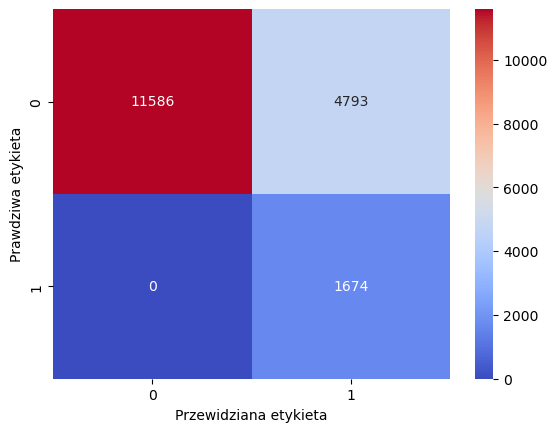

In [10]:
cm = confusion_matrix(y_test, final_predictions)
sns.heatmap(cm, annot=True, fmt="d", cmap="coolwarm")
plt.ylabel("Prawdziwa etykieta")
plt.xlabel("Przewidziana etykieta")
plt.show()

W przypadku zbiorów niezbalansowanych krzywa PR jest lepsza od ROC, ponieważ skupia się tylko na klasie pozytywnej. Krzywa ROC może być zbyt optymistyczna ponieważ zawiera ona TN (podczas liczenia FPR), których przez niezbalansowanie klas jest bardzo dużo

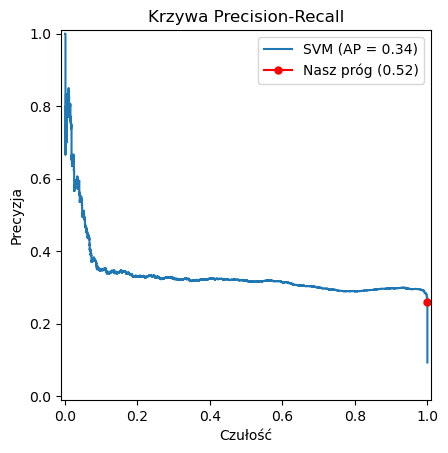

In [11]:
PrecisionRecallDisplay.from_predictions(y_test, y_test_scores, name="SVM")

precision, recall, pr_thresholds = precision_recall_curve(y_test, y_test_scores)
pr_thresholds_padded = np.append(pr_thresholds, pr_thresholds[-1]) 
idx_pr = np.argmin(np.abs(pr_thresholds_padded - best_thr))

plt.plot(recall[idx_pr], precision[idx_pr], marker="o", markersize=5, color="red", 
         label=f"Nasz próg ({best_thr:.2f})")
plt.title("Krzywa Precision-Recall")
plt.ylabel("Precyzja")
plt.xlabel("Czułość")
plt.legend()

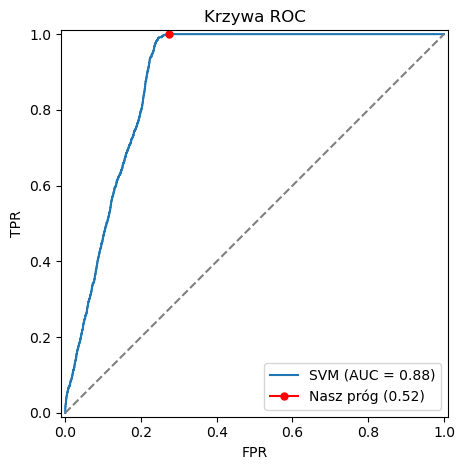

In [12]:
RocCurveDisplay.from_predictions(y_test, y_test_scores, name="SVM")

fpr, tpr, roc_thresholds = roc_curve(y_test, y_test_scores)
idx_roc = np.argmin(np.abs(roc_thresholds - best_thr))

plt.plot(fpr[idx_roc], tpr[idx_roc], marker="o", markersize=5, color="red", 
         label=f"Nasz próg ({best_thr:.2f})")
plt.plot([0, 1], [0, 1], color='gray', linestyle="--")

plt.title("Krzywa ROC")
plt.legend()
plt.tight_layout()
plt.ylabel("TPR")
plt.xlabel("FPR")
plt.show()

# Wnioski
Zadanie udało się wykonać - wytrenowany został model który w żadnym przypadku nie przewiduje FN, więc Ziemia nie została zniszczona. Niestety, koszt tego przedsięwzięcia okazał się duży - prawie 5 tys. niegroźnych asteroid zostało błędnie sklasyfikowanych. Ten wynik ma mimo wszystko sens przy SVM, ponieważ jego działanie polega na rysowaniu "baniek", odgradzających klasy. Ponieważ chcemy zadbać o to by każdy obiekt groźny został sklasyfikowany poprawnie, to te bańki muszą rozrosnąć się na tyle, żeby pochłonąć wiele niegroźnych asteroid.